# ex-7 — six-factor model: rotation and identification across the spectrum

The ex-6 machinery on a **6-factor** model calibrated to stylized real-data magnitudes —
factor vols ordered like a typical equity style stack, with adjacent spike gaps ranging
from comfortable to nearly degenerate, so the identification behavior seen in the 3-factor
pair now plays out at several points along the spectrum at once.

| j | stylized name | vol | $\rho_j = c_j\sigma_j^2$ | $\rho_j/\rho_{j+1}$ |
|---|---|---|---|---|
| 1 | Market  | 16.0% | 0.0320 | 3.20 |
| 2 | Value   | 10.0% | 0.0100 | 1.56 |
| 3 | Size    |  8.0% | 0.0064 | 1.51 |
| 4 | Momentum|  6.5% | 0.0042 | **1.17** |
| 5 | Quality |  6.0% | 0.0036 | 2.25 |
| 6 | LowVol  |  4.0% | 0.0016 | — |

(Levels are stylized, not fitted — chosen so the 4–5 pair is deeply degenerate, 2–3 and
3–4 marginal, and 1–2 / 5–6 comfortable. Market keeps $c_1 = 1.25$ via the $\beta$ mean;
other prevalences are 1.)

Route: record coordinates (classes carried from ex-6, already $k$-generic) → run/load the
$n$-sweep at $p{=}3000$ → derive + verify → scalar overview across all six factors →
**successive factor-pair planes** with overlaid clouds and mean arrows. Factor coloring is
consistent throughout: 1 blue, 2 orange, 3 green, 4 red, 5 purple, 6 brown.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import grid, Row, BoxDist, RefOverlay, DiskDensity, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = DATA_DIR / "ex-7_six_factor"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


K = 6
VOLS = [0.16, 0.10, 0.08, 0.065, 0.06, 0.04]
NAMES = ["Market", "Value", "Size", "Momentum", "Quality", "LowVol"]

model = ModelSpec(
    k_factors=K,
    factor_vols=VOLS,
    beta_samplers=[{"distribution": "normal", "loc": 1.0, "scale": 0.5}]
                  + [{"distribution": "normal", "loc": 0.0, "scale": 1.0}] * (K - 1),
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 600, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"

rho = np.array([1.25] + [1.0] * (K - 1)) * np.array(VOLS) ** 2
print("rho:", np.round(rho, 5))
print("adjacent ratios:", np.round(rho[:-1] / rho[1:], 2))

rho: [0.032   0.01    0.0064  0.00423 0.0036  0.0016 ]
adjacent ratios: [3.2  1.56 1.51 1.17 2.25]


## Step 1–2 — record + sweeps

Classes carried verbatim from ex-6 — `record()` already loops over $k$, so nothing changes
for six factors: `hb1..hb6` (coordinates of $\Pi h_j$ in the $b$-basis) and `nu1..nu6`
(components of $\hat\nu_j$) per replicate and factor. Two sweeps, $R = 600$ each, cached
to `ex7_df_{n,p}.parquet`:

* **growing n** at $p{=}3000$ — $n \in \{20, 63, 250\}$: the axis that resolves
  identification;
* **growing p** at $n{=}63$ — $p \in \{100, \dots, 50{,}000\}$: the axis that removes the
  finite-$p$ elevation but cannot fix the finite-$n$ rotation.


In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the finite-p split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H
        in_subspace = (coeffs ** 2).sum(axis=0)
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,
                "h_coords": coeffs}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ProjectedSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        return [{
            "n": n, "p": p, "j": j + 1,
            "sin2_j": float(merged["sin2_j"][j]),
            "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
            "rotation": float(merged["rotation"][j]),
            "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
            **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
            **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
        } for j in range(k)]


design_n = DesignSpec(
    n_values=[20, 63, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = {f"hb{i}" for i in range(1, K + 1)} | {f"nu{i}" for i in range(1, K + 1)}


def load_or_run(path, design, label):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps
                and d["j"].max() == K):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cache mismatch — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_n = load_or_run(DATA_DIR / "ex7_df_n.parquet", design_n, "growing-n")
df_p = load_or_run(DATA_DIR / "ex7_df_p.parquet", design_p, "growing-p")


growing-n: loaded cached sweep ex7_df_n.parquet (10,800 rows)


replicate:   0%|          | 0/600 [00:00<?, ?rep/s]

replicate:   0%|          | 1/600 [00:00<01:14,  8.08rep/s]

replicate:   0%|          | 2/600 [00:00<01:27,  6.84rep/s]

replicate:   0%|          | 3/600 [00:00<01:28,  6.77rep/s]

...

replicate: 100%|█████████▉| 598/600 [01:33<00:00,  6.43rep/s]

replicate: 100%|█████████▉| 599/600 [01:33<00:00,  6.45rep/s]

replicate: 100%|██████████| 600/600 [01:33<00:00,  6.45rep/s]

replicate: 100%|██████████| 600/600 [01:33<00:00,  6.40rep/s]

growing-p: ran sweep (21,600 rows) → ex7_df_p.parquet


## Step 3 — derive + verify

Same derivation as ex-6, $k$-generic: in-subspace rotation from coordinates, cross-checked
against the exact-split identity; unit-normalized sign-folded disk coordinates for all six
axes.

In [3]:
HB = [f"hb{i}" for i in range(1, K + 1)]
NU = [f"nu{i}" for i in range(1, K + 1)]


def derive(df):
    C, W = df[HB].to_numpy(), df[NU].to_numpy()
    norm2 = (C ** 2).sum(axis=1)
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    nrm = np.sqrt(norm2)
    out = df.assign(sin2_in=1.0 - cjj ** 2 / norm2)
    out = out.assign(diff_in_rot=out["sin2_in"] - df["rotation"])
    for i in range(K):
        out[f"hd{i + 1}"] = sgn_h * C[:, i] / nrm
        out[f"nud{i + 1}"] = sgn_nu * W[:, i]
    return out


df_n, df_p = derive(df_n), derive(df_p)

for nm, d in (("growing-n", df_n), ("growing-p", df_p)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|‖c‖² − (1−oos)| max = "
          f"{((d[HB] ** 2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")


growing-n: |sin2_in(coords) − sin2_in(identity)| max = 3.40e-14;  |‖c‖² − (1−oos)| max = 5.55e-17
growing-p: |sin2_in(coords) − sin2_in(identity)| max = 2.58e-14;  |‖c‖² − (1−oos)| max = 5.55e-17


## Step 4 — scalar overview: all six factors at once

In-subspace rotation distribution per factor with the $k\times k$ limit overlaid. The
spike-gap table above predicts the ordering: Market clean at every $n$; Value/Size
moderate; **Momentum and Quality (the 1.17× pair) worst**, with heavy upper tails at
$n=20$ and $63$; LowVol better than its neighbors despite the smallest vol, because its
gap to Quality is comfortable.

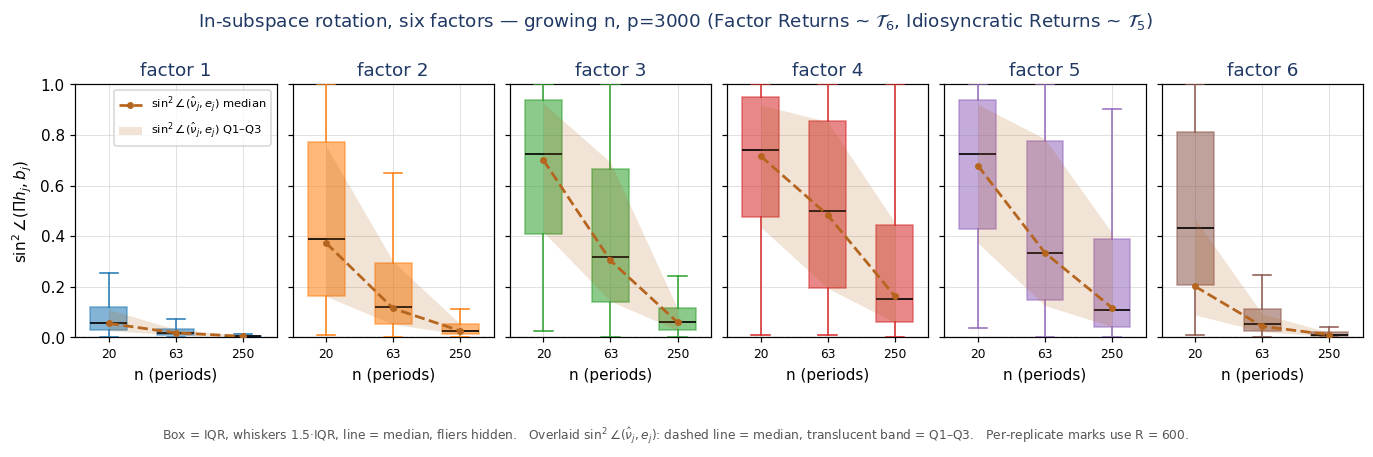

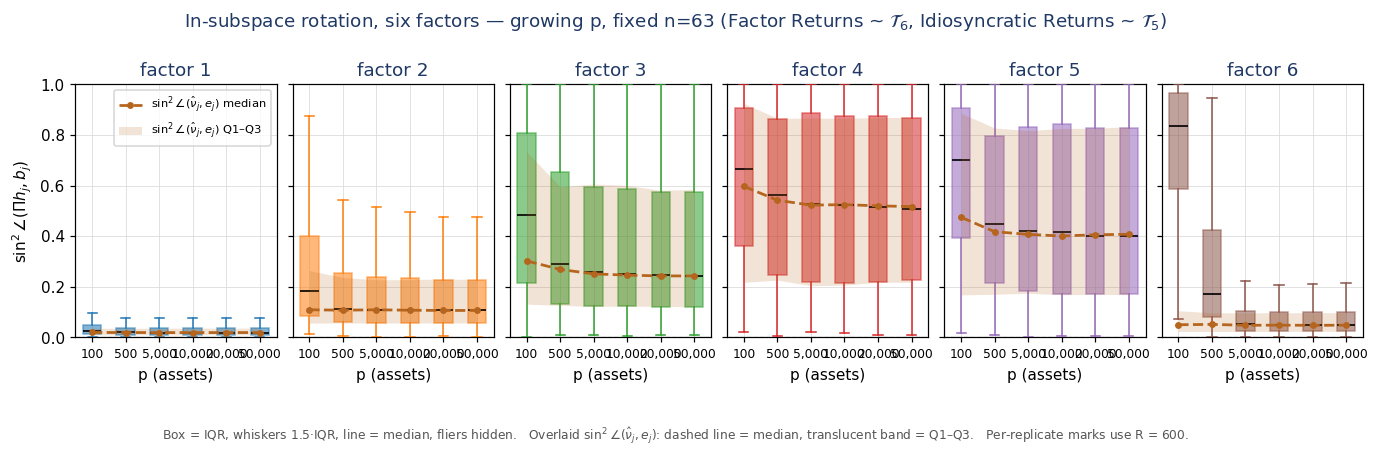

In [4]:
for df, key, lab, stem in ((df_n, "n", "growing n, p=3000", "ex7_insub_dist_n"),
                           (df_p, "p", "growing p, fixed n=63", "ex7_insub_dist_p")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation, six factors — {lab} {_TAILS}",
                  out_path=OUT_DIR / stem)
    show(fig)


## Step 5 — successive factor-pair planes, both sweeps

Two figures per adjacent pair $(b_j, b_{j+1})$, both clouds overlaid with mean arrows:

* **growing n** (rows $n = 20, 63, 250$) — identification resolving as the spike gap
  sharpens; read arrow lengths as identification scores;
* **growing p** (rows $p = 100, 5000, 50000$, plus the $\hat\nu_j$ **limit clouds** in the
  $(e_j, e_{j+1})$ plane as the bottom row) — the finite-$p$ clouds tighten onto the limit
  clouds, but the limit itself keeps whatever confusion $n{=}63$ leaves: for
  Momentum–Quality the p=50,000 row and the limit row are equally smeared, the visual
  statement that more assets cannot resolve a factor-space degeneracy.


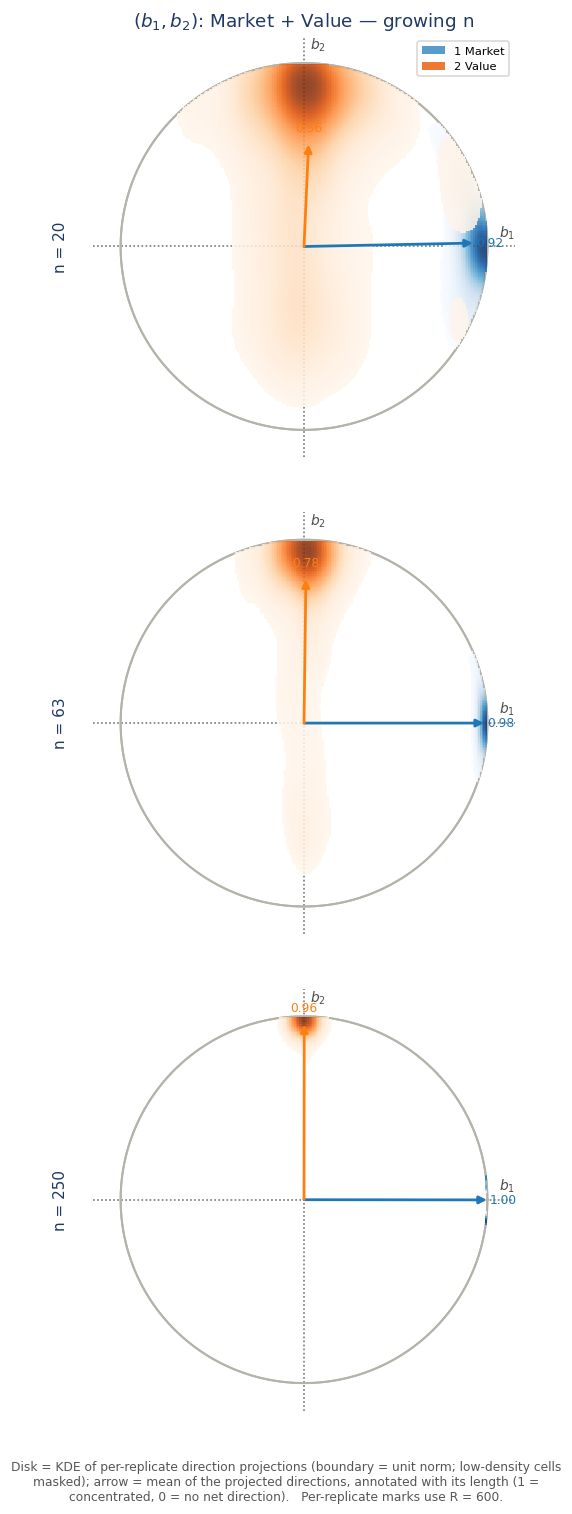

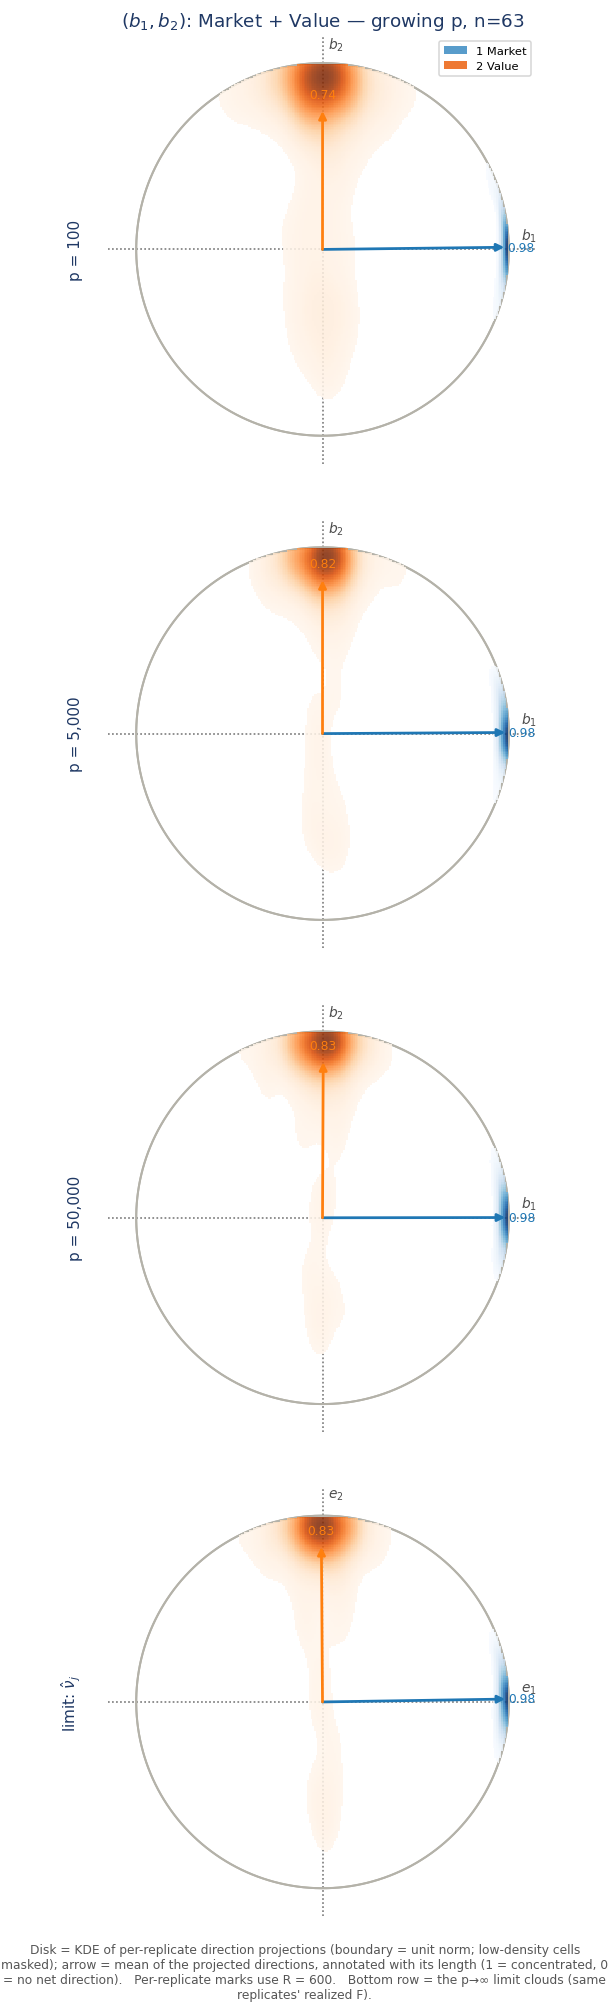

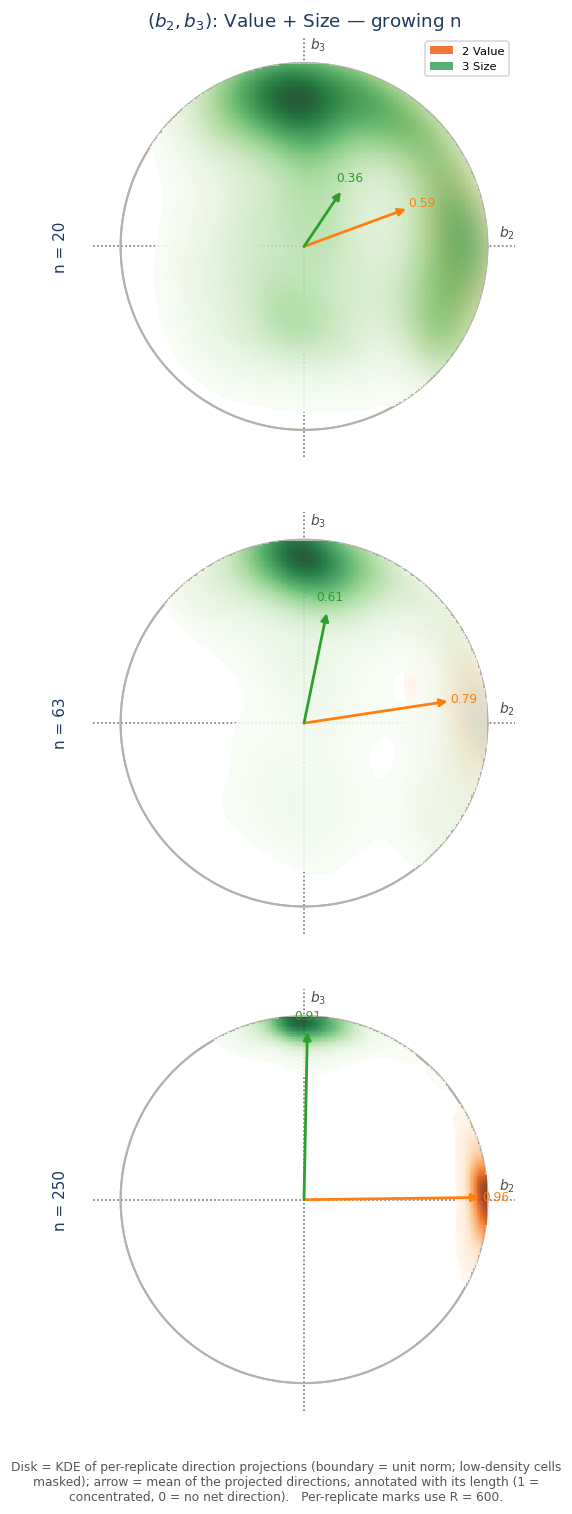

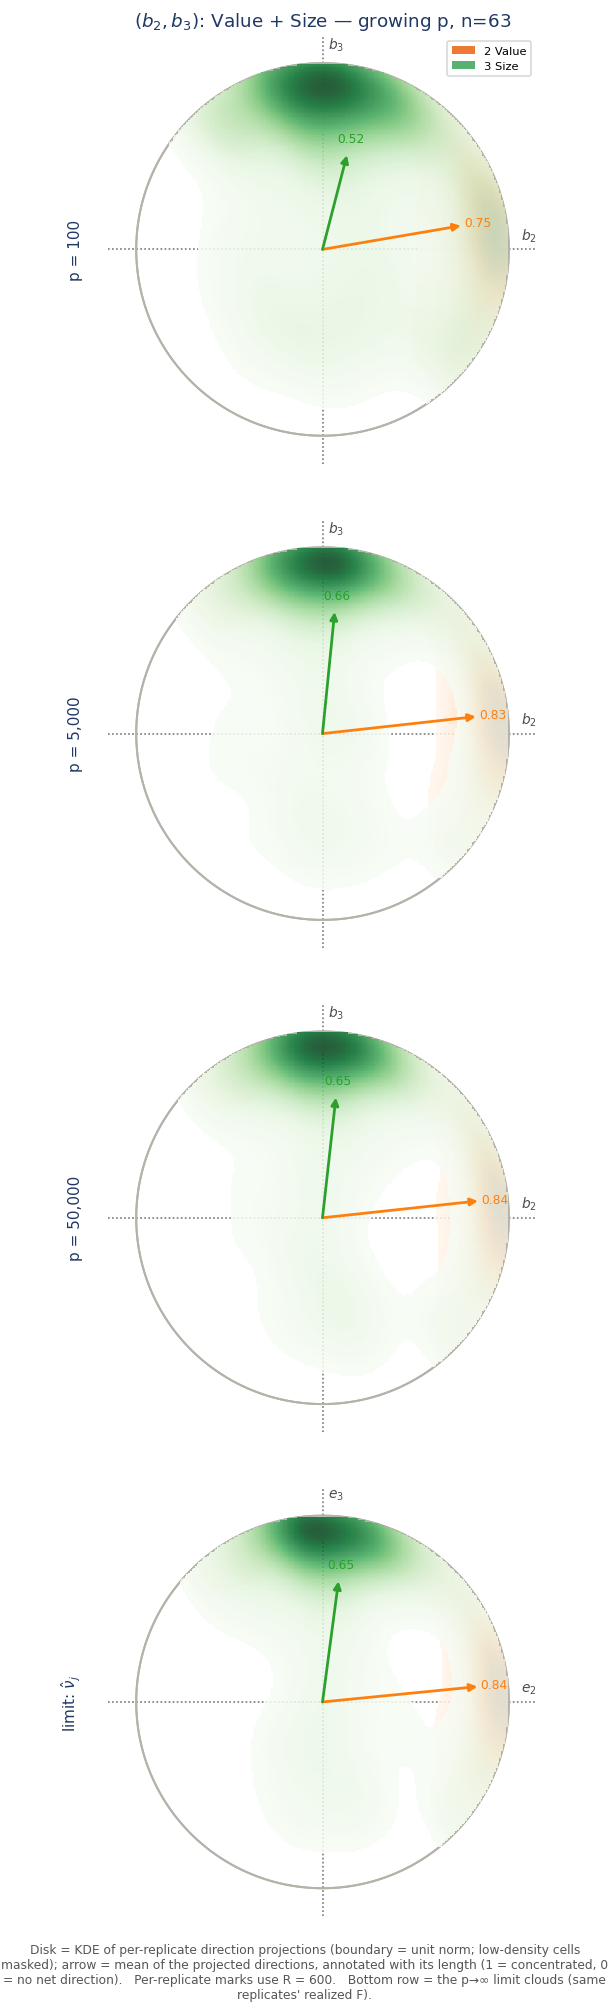

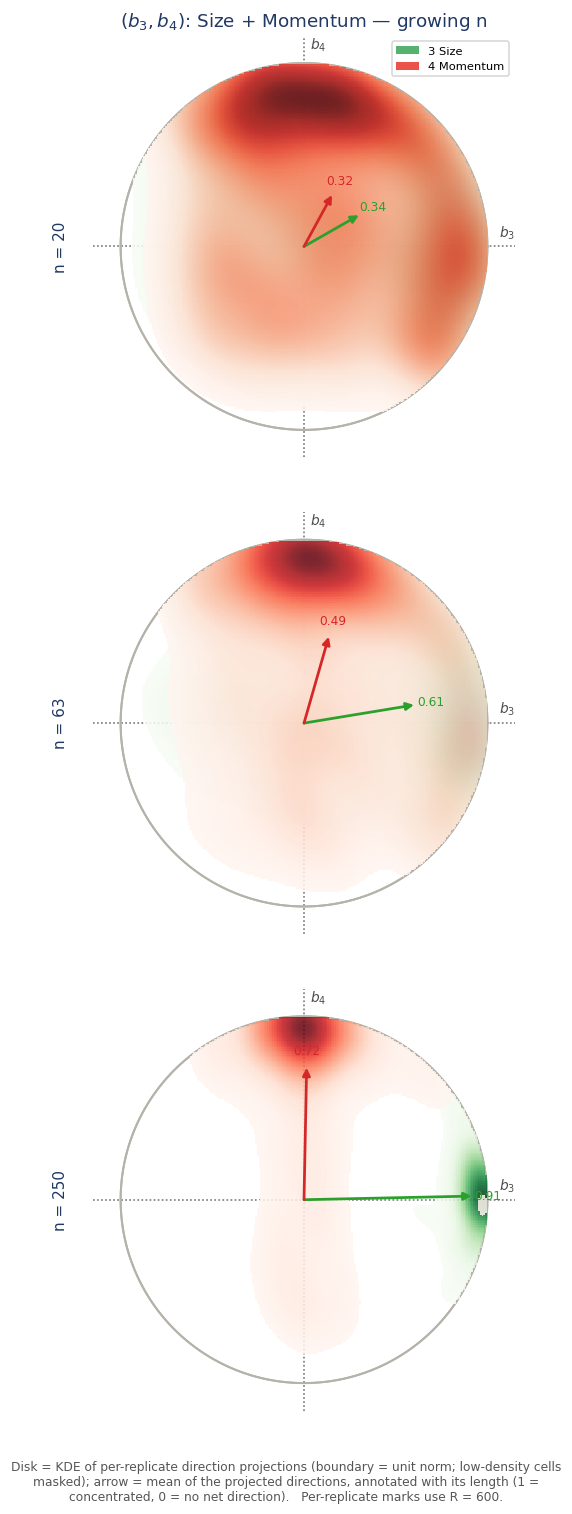

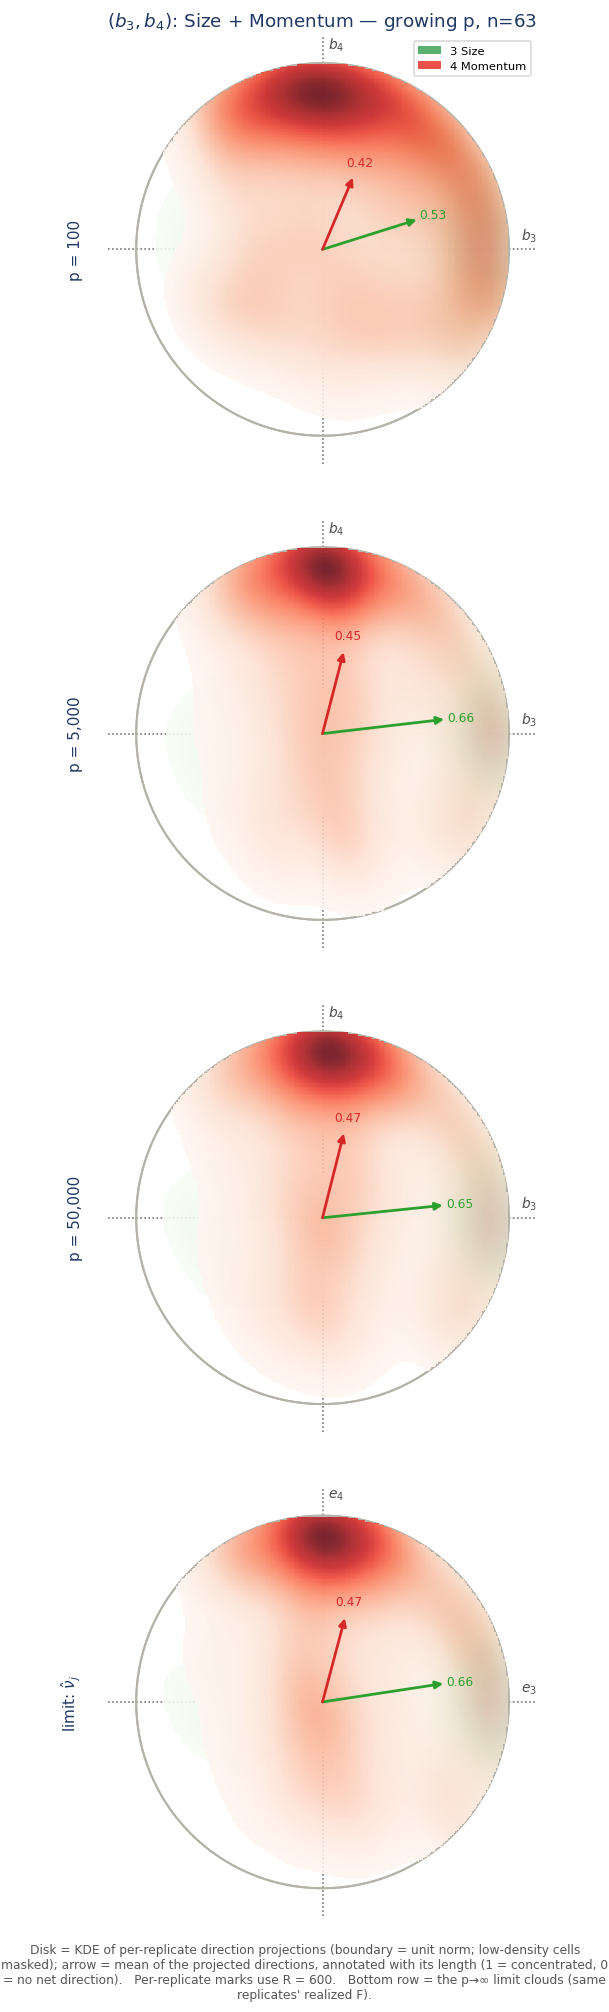

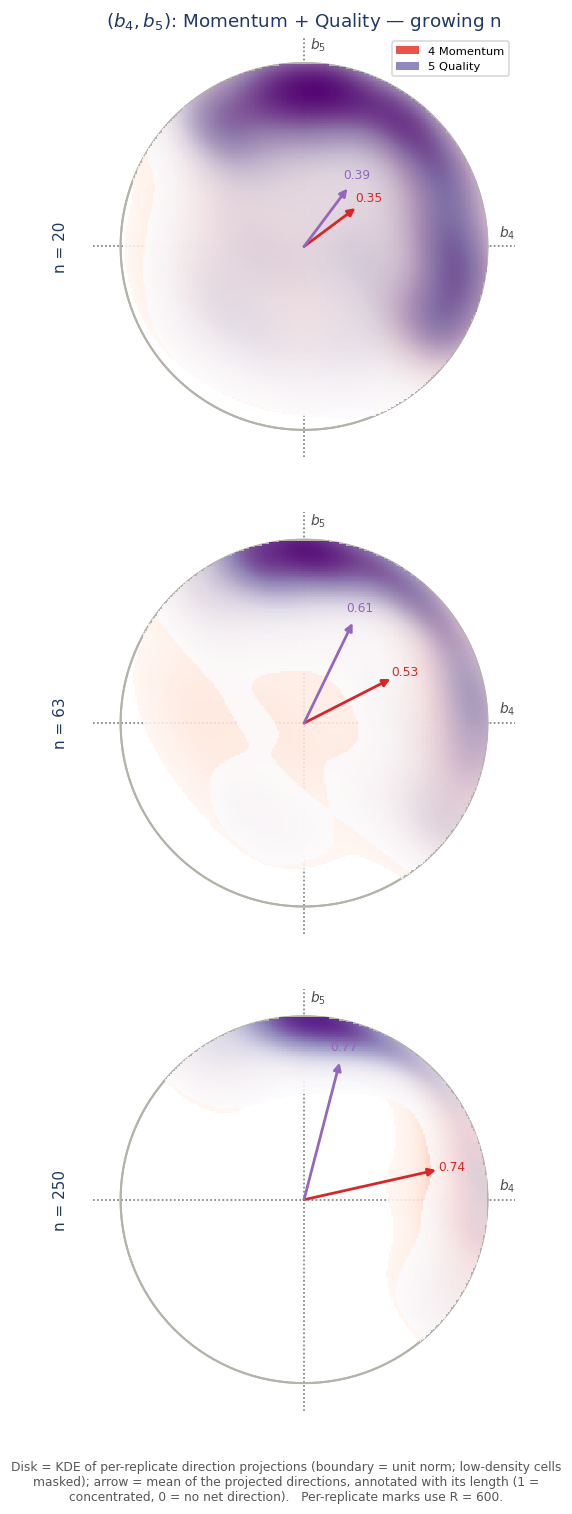

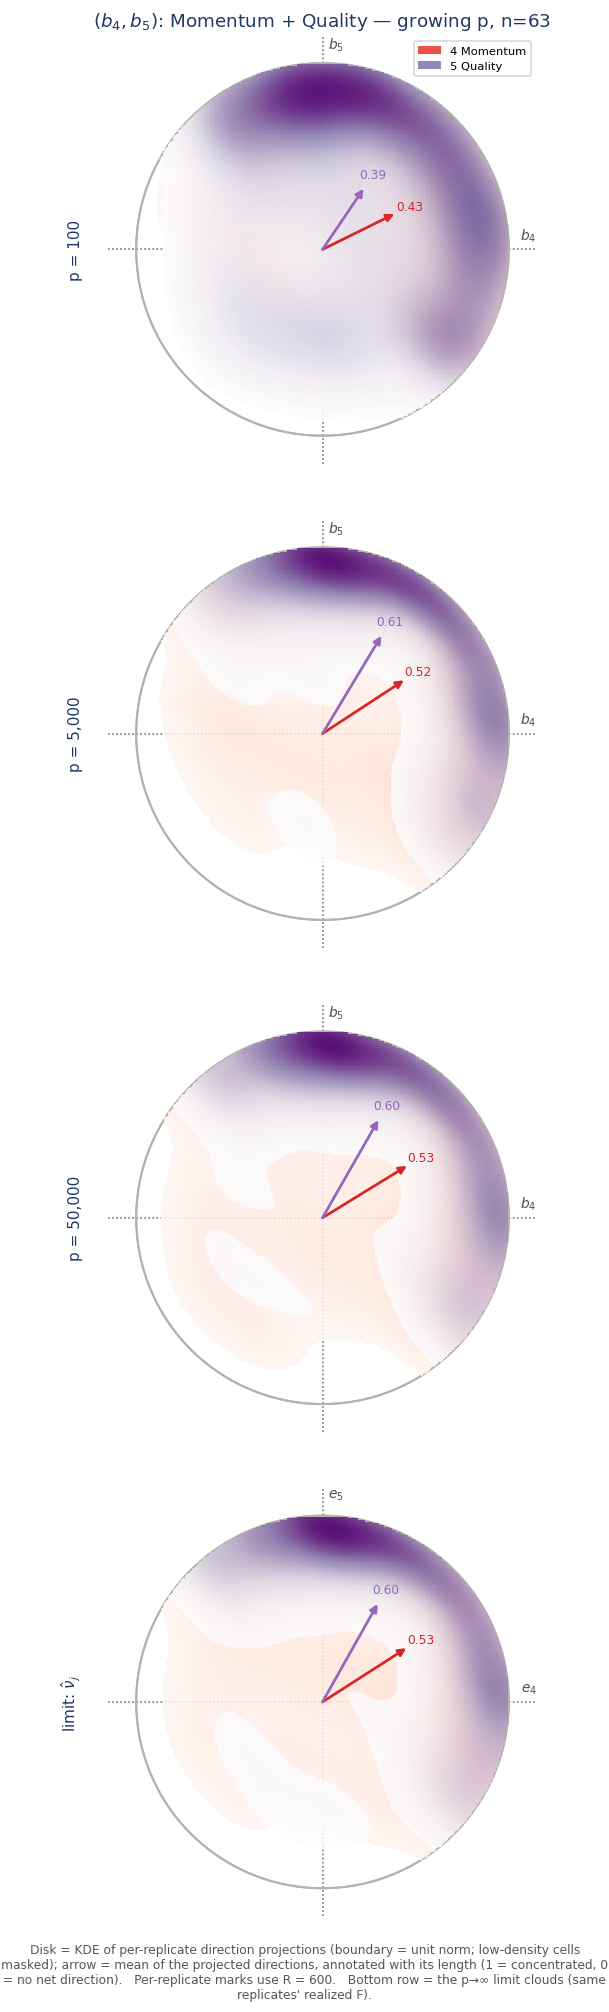

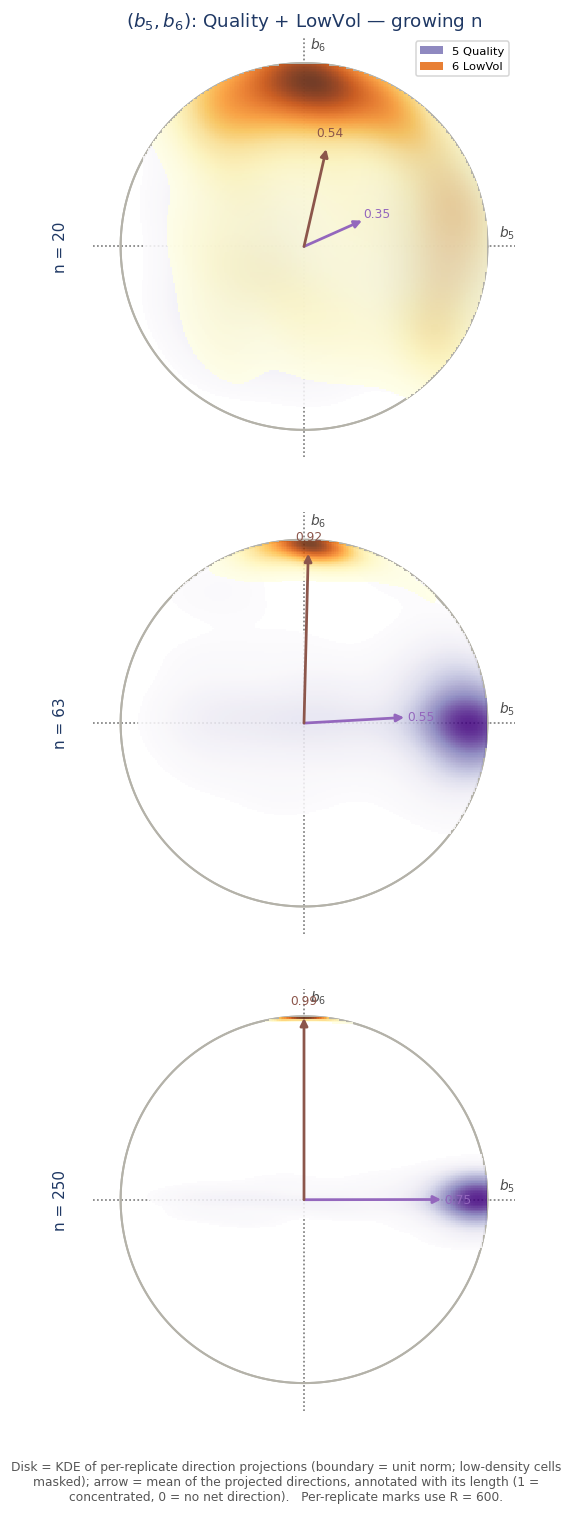

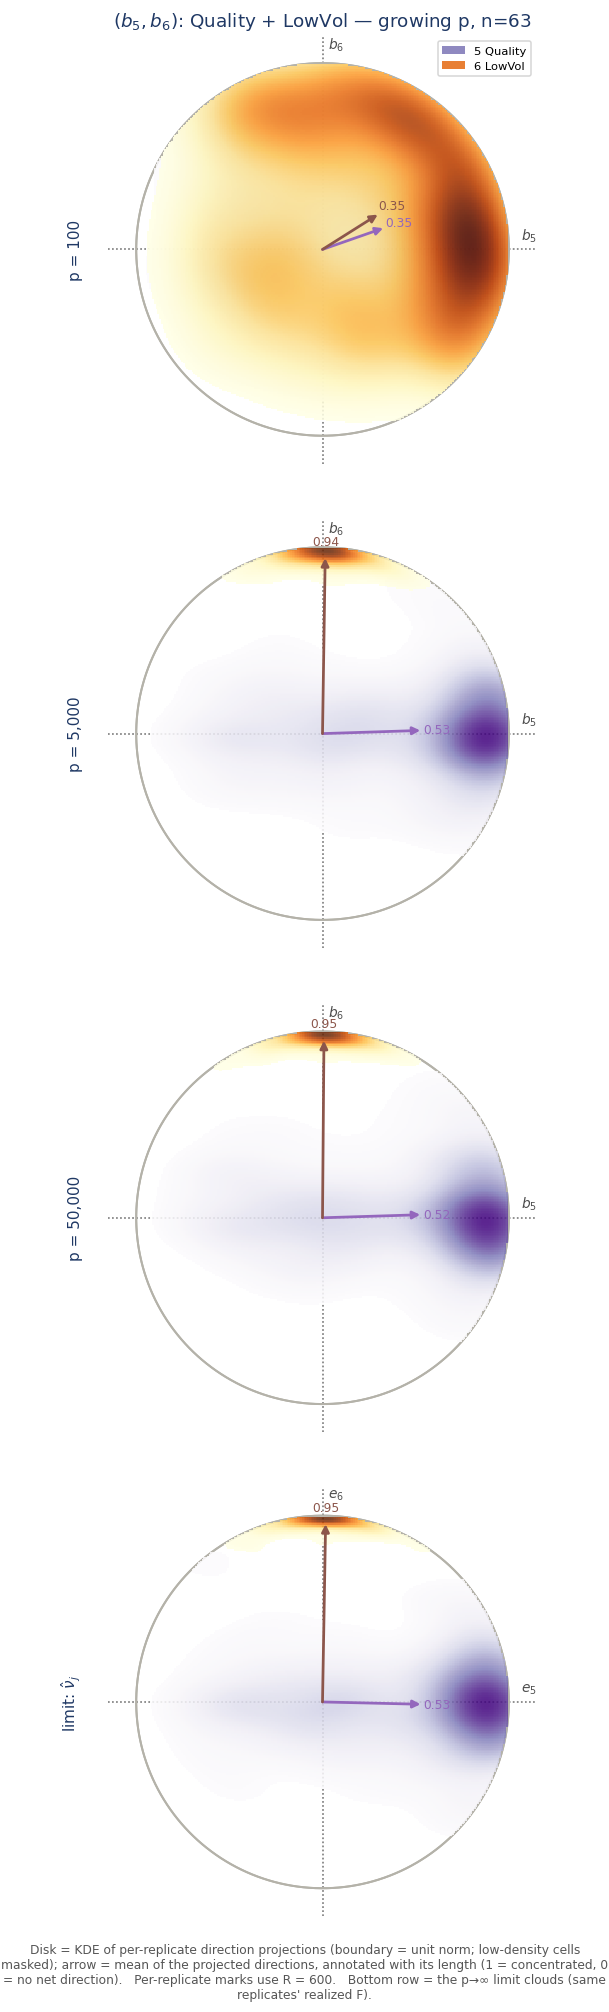

In [5]:
def pair_disks(f1, f2):
    """Overlaid clouds + mean arrows for the (b_f1, b_f2) plane, one mark per factor."""
    def marks(at, xc=None, yc=None):
        xc, yc = xc or f"hd{f1}", yc or f"hd{f2}"
        return [DiskDensity(xc, yc, factor=f1, at=at, mean_arrow=True,
                            label=f"{f1} {NAMES[f1 - 1]}",
                            labels=(rf"$b_{f1}$", rf"$b_{f2}$")),
                DiskDensity(xc, yc, factor=f2, at=at, mean_arrow=True,
                            label=f"{f2} {NAMES[f2 - 1]}")]
    return marks


for f1 in range(1, K):
    f2 = f1 + 1
    marks = pair_disks(f1, f2)

    # growing n at p=3000
    fig, _ = grid(
        df_n, "n", factors=[1],
        col_titles=[rf"$(b_{f1}, b_{f2})$: {NAMES[f1 - 1]} + {NAMES[f2 - 1]} — growing n"],
        rows=[Row(marks({"n": v}), ylabel=f"n = {v}", height=1.0) for v in (20, 63, 250)],
        sharey=False, figsize=(5.4, 14.0),
        out_path=OUT_DIR / f"ex7_plane_b{f1}b{f2}")
    show(fig)

    # growing p at n=63, with the p→∞ limit clouds (ν̂ in the e-basis) as the bottom row
    fig, _ = grid(
        df_p, "p", factors=[1],
        col_titles=[rf"$(b_{f1}, b_{f2})$: {NAMES[f1 - 1]} + {NAMES[f2 - 1]} — growing p, n=63"],
        rows=[Row(marks({"p": v}), ylabel=f"p = {v:,}", height=1.0)
              for v in (100, 5000, 50000)]
             + [Row([DiskDensity(f"nud{f1}", f"nud{f2}", factor=f1, at={"p": 50000},
                                 mean_arrow=True, label=f"{f1} {NAMES[f1 - 1]}",
                                 labels=(rf"$e_{f1}$", rf"$e_{f2}$")),
                     DiskDensity(f"nud{f1}", f"nud{f2}", factor=f2, at={"p": 50000},
                                 mean_arrow=True, label=f"{f2} {NAMES[f2 - 1]}")],
                    ylabel=r"limit: $\hat\nu_j$", height=1.0)],
        sharey=False, figsize=(5.4, 18.6),
        caption_extra="Bottom row = the p→∞ limit clouds (same replicates' realized F).",
        out_path=OUT_DIR / f"ex7_plane_b{f1}b{f2}_growing_p")
    show(fig)


## Step 6 — the numbers

In [6]:
def tail_table(df, key):
    t = (df.groupby([key, "j"])["sin2_in"]
           .agg(median="median", q3=lambda s: s.quantile(0.75),
                p95=lambda s: s.quantile(0.95),
                frac_gt_half=lambda s: (s > 0.5).mean())
           .round(4)
           .reset_index())
    t.insert(2, "name", t["j"].map(lambda j: NAMES[j - 1]))
    return t

print("growing n (p=3000):")
display(tail_table(df_n, "n"))
print("growing p (n=63):")
display(tail_table(df_p, "p"))


growing n (p=3000):


,n,j,name,median,q3,p95,frac_gt_half
0,20,1,Market,0.0556,0.1188,0.3767,0.0367
1,20,2,Value,0.3878,0.7717,0.9863,0.4267
2,20,3,Size,0.7251,0.9377,0.9977,0.6817
3,20,4,Momentum,0.7423,0.9519,0.9974,0.7283
4,20,5,Quality,0.7234,0.9366,0.9979,0.6983
5,20,6,LowVol,0.4335,0.8136,0.9893,0.4433
6,63,1,Market,0.0176,0.0348,0.0837,0.0050
7,63,2,Value,0.1201,0.2959,0.9005,0.1717
8,63,3,Size,0.3165,0.6662,0.9809,0.3567
9,63,4,Momentum,0.4989,0.8564,0.9944,0.5000


growing p (n=63):


,p,j,name,median,q3,p95,frac_gt_half
0,100,1,Market,0.0259,0.0480,0.1374,0.0033
1,100,2,Value,0.1823,0.4020,0.9476,0.1900
2,100,3,Size,0.4827,0.8074,0.9905,0.4900
3,100,4,Momentum,0.6661,0.9050,0.9933,0.6250
4,100,5,Quality,0.7000,0.9077,0.9949,0.6533
5,100,6,LowVol,0.8356,0.9656,0.9985,0.8117
6,500,1,Market,0.0204,0.0369,0.0927,0.0017
7,500,2,Value,0.1110,0.2535,0.8613,0.1183
8,500,3,Size,0.2891,0.6531,0.9830,0.3217
9,500,4,Momentum,0.5635,0.8634,0.9921,0.5400


---
## Change log

- **2026-08-03**: new notebook — the ex-6 pipeline on a stylized six-factor model
  (Market/Value/Size/Momentum/Quality/LowVol vols, adjacent spike gaps from 3.2× down to
  1.17×). Records the full 6-vector projection coordinates per replicate (classes carried
  from ex-6, k-generic), n-sweep at p=3000, R=600, cached to `ex7_df_n.parquet`. Figures:
  six-factor scalar overview + the five successive factor-pair plane disks with overlaid
  clouds and mean arrows, factor coloring consistent with the theme (1 blue … 6 brown).
  Figures → `nb_outputs/ex-7_six_factor/`.
- **2026-08-03 (b)**: added the growing-p sweep at fixed n=63 (`ex7_df_p.parquet`, same
  seed/R): scalar overview across p, and per-pair growing-p plane figures with the
  $\hat\nu_j$ limit clouds as the bottom row.
